In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX, DelimitedFiles;
using JJDFTX: kinetic_energy
interpolate = pyimport("scipy.interpolate").interp1d

Your version of python is not linked to helper_scripts.py
Congratulations- Your version of python is linked to the Atomic Simulation Environment


PyObject <class 'scipy.interpolate.interpolate.interp1d'>

In [70]:
export_momentum("wannier", spin=Val('d'))
export_hwannier("wannier", spin=Val('d'))
export_heph("wannier", spin=Val('d'));

In [6]:
export_hwannier("../../BN3BC_Buckled/phonon11/wannier")
export_heph("../../BN3BC_Buckled/phonon11/wannier");
export_momentum("../../BN3BC_Buckled/phonon11/wannier");

In [134]:
export_hwannier("../../BN3BC_Buckled/phonon22/wannier")
export_heph("../../BN3BC_Buckled/phonon22/wannier");
export_momentum("../../BN3BC_Buckled/phonon22/wannier");

In [4]:
Buckled_Wannier_Dir11 = "../../BN3BC_Buckled/phonon11/"
Buckled_Wannier_Dir22 = "../../BN3BC_Buckled/phonon22/"

"../../BN3BC_Buckled/phonon22/"

In [5]:
force_matrix, cellph_map = phonon_force_matrix(Buckled_Wannier_Dir11*"BN3BC");
force_matrix22, cellph_map22 = phonon_force_matrix(Buckled_Wannier_Dir22*"BN3BC");

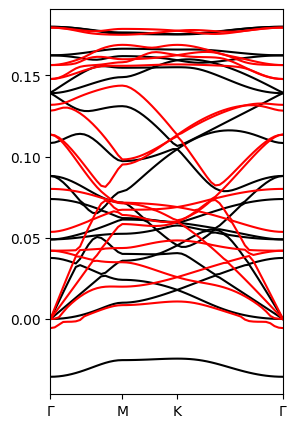

(0.0, 55.0)

In [7]:
dispersion = phonon_dispersion(force_matrix, cellph_map, return_negative=true);
dispersion22 = phonon_dispersion(force_matrix22, cellph_map22, return_negative=true);
figure(figsize=(3, 5))

plot(dispersion, color="black")
plot(dispersion22, color="red")

label_plots()
#ylim(-0.02, 0)

In [54]:
# Find DOS
Energies, DOS = density_of_states(Hwannier_Buckled, cellmap_Buckled, Val(2), histogram_width=100, mesh=30, monte_carlo=true, num_blocks=100);

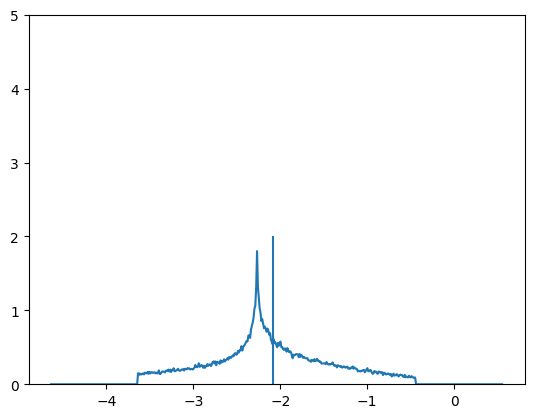

(0.0, 5.0)

In [55]:
plot(Energies, DOS)
vlines([-2.088258123632972], 0, 2)
ylim(0, 5)
#xlim(-3, -1)

In [56]:
Es, Cs = find_chemical_potential(Energies, DOS)
μ = Es[argmin(abs.(Cs .- 0.5))]
println("Chemical potential: $(μ)")
println("gμ: $(DOS[argmin(abs.(Energies .- μ))])")

Chemical potential: -2.1873546412595877
gμ: 0.7566666666666667


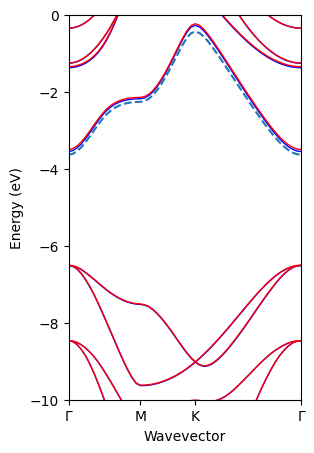

(-10.0, 0.0)

In [53]:
figure(figsize=(3,5))
plot_bands(Hwannier_Buckled, cellmap_Buckled, linestyle="dashed")
plot_bands("../BN3BC.bands.eigenvals", spin=2, linewidth=1)
ylim(-10, 0)

In [102]:
meshing=20
num_blocks=1000
histogram_width=100

Alternative_JDOS = zeros(100)
for i in 1:num_blocks
    k = vcat(rand(2, meshing^2), zeros(1, meshing^2))
    kprime = vcat(rand(2, meshing^2), zeros(1, meshing^2))

    eks = wannier_bands(Hwannier_Buckled, cellmap_Buckled, k)[1]
    ekprimes = wannier_bands(Hwannier_Buckled, cellmap_Buckled, kprime)[1]
    eks = np.repeat(np.reshape(eks, (meshing^2, 1) ), meshing^2, axis=1)
    ekprimes = np.repeat(np.reshape(ekprimes, (1, meshing^2) ),meshing^2,  axis=0)
    f2 = 1 .- np.heaviside(μ .- ekprimes, 0.5)
    f1 = np.heaviside(μ .- eks, 0.5)

    Alternative_JDOS += first(np.histogram(ekprimes-eks, bins=round(Int, histogram_width), weights=f1 .* f2, range=(0, 1)))*(1/meshing)^4*histogram_width*(1/num_blocks)
end

In [57]:
fomega = interpolate(Energies .- μ, DOS);

In [116]:
JDOS = Float64[]
omegarange = range(0, 1, length=100)
for ω in omegarange
    push!(JDOS, pyintegrate.quad(x->fomega(x)[1]*fomega(x-ω)[1], 0, ω)[1])
end

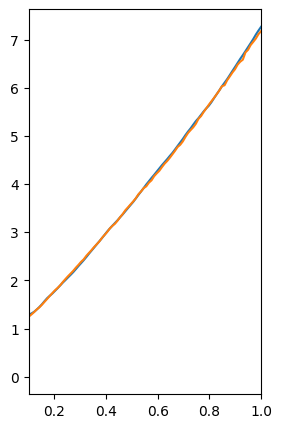

(0.1, 1.0)

In [117]:
figure(figsize=(3, 5))
plot(omegarange[2:end], omegarange[2:end] ./ JDOS[2:end])
plot(range(0, 1, length=100), range(0, 1, length=100) ./ Alternative_JDOS)
xlim(0.1, 1)
#ylim(0, 0.2)

In [120]:
np.savetxt("JDOS.txt", hcat(omegarange[2:end], JDOS[2:end], Alternative_JDOS[2:end]), header="omegas, jdos, jdos_alternative")

In [23]:
# DOS from the full Wannier interpolation
println("DOS at the fermi level is: $(DOS[argmin(abs.(Energies .+2.088258123632972))])")

DOS at the fermi level is: 0.739111111111111


In [16]:
# Calculate Conductivity
es, cs = drude_conductivity(lattice_vectors, HwannierUp, cellmapUp, PwannierUp, mesh=20, num_blocks=500,
    degeneracy=2, histogram_width=100)

Block: 1
Block: 2
Block: 3
Block: 4
Block: 5
Block: 6
Block: 7
Block: 8
Block: 9
Block: 10
Block: 11
Block: 12
Block: 13
Block: 14
Block: 15
Block: 16
Block: 17
Block: 18
Block: 19
Block: 20
Block: 21
Block: 22
Block: 23
Block: 24
Block: 25
Block: 26
Block: 27
Block: 28
Block: 29
Block: 30
Block: 31
Block: 32
Block: 33
Block: 34
Block: 35
Block: 36
Block: 37
Block: 38
Block: 39
Block: 40
Block: 41
Block: 42
Block: 43
Block: 44
Block: 45
Block: 46
Block: 47
Block: 48
Block: 49
Block: 50
Block: 51
Block: 52
Block: 53
Block: 54
Block: 55
Block: 56
Block: 57
Block: 58
Block: 59
Block: 60
Block: 61
Block: 62
Block: 63
Block: 64
Block: 65
Block: 66
Block: 67
Block: 68
Block: 69
Block: 70
Block: 71
Block: 72
Block: 73
Block: 74
Block: 75
Block: 76
Block: 77
Block: 78
Block: 79
Block: 80
Block: 81
Block: 82
Block: 83
Block: 84
Block: 85
Block: 86
Block: 87
Block: 88
Block: 89
Block: 90
Block: 91
Block: 92
Block: 93
Block: 94
Block: 95
Block: 96
Block: 97
Block: 98
Block: 99
Block: 100
Block: 1

([-100.0, -99.989999499975, -99.97999899995, -99.969998499925, -99.9599979999, -99.949997499875, -99.93999699985, -99.929996499825, -99.9199959998, -99.909995499775  …  99.909995499775, 99.9199959998, 99.929996499825, 99.93999699985, 99.949997499875, 99.9599979999, 99.969998499925, 99.97999899995, 99.989999499975, 100.0], [0.0 0.0 0.0; 0.0 0.0 0.0; … ; 0.0 0.0 0.0; 0.0 0.0 0.0]

[0.0 0.0 0.0; 0.0 0.0 0.0; … ; 0.0 0.0 0.0; 0.0 0.0 0.0]

[0.0 0.0 0.0; 0.0 0.0 0.0; … ; 0.0 0.0 0.0; 0.0 0.0 0.0])

In [17]:
(cs[argmin(abs.(es .+ 2.0935087167619026)), 2, 2]+cs[argmin(abs.(es .+ 2.0935087167619026)), 1, 1])/2

1.7684791424699235

In [18]:
println("The conductivity is $(100*1.7684791424699235/(2/pi))% of graphene at 0.5 eV doping") 

The conductivity is 277.79205410051446% of graphene at 0.5 eV doping


In [41]:
polarizations = []
for (i,k) in enumerate(kpoints[1:50])
    println(i); flush(stdout)
    push!(polarizations, ImΠ(HwannierUp, cellmapUp, lattice_vectors, k, -2.0935087167619026, Val(2), histogram_width=100, mesh=50, 
            degeneracy=2, monte_carlo=true))
end

1
[0.0, 0.0, 0.0]
2
[0.0058823529412, 0.0, 0.0]
3
[0.0117647058824, 0.0, 0.0]
4
[0.0176470588236, 0.0, 0.0]
5
[0.0235294117648, 0.0, 0.0]
6
[0.029411764706, 0.0, 0.0]
7
[0.0352941176472, 0.0, 0.0]
8
[0.0411764705884, 0.0, 0.0]
9
[0.0470588235296, 0.0, 0.0]
10
[0.0529411764708, 0.0, 0.0]
11
[0.058823529412, 0.0, 0.0]
12
[0.0647058823532, 0.0, 0.0]
13
[0.0705882352944, 0.0, 0.0]
14
[0.0764705882356, 0.0, 0.0]
15
[0.0823529411768, 0.0, 0.0]
16
[0.088235294118, 0.0, 0.0]
17
[0.0941176470592, 0.0, 0.0]
18
[0.1000000000004, 0.0, 0.0]
19
[0.1058823529416, 0.0, 0.0]
20
[0.1117647058828, 0.0, 0.0]
21
[0.117647058824, 0.0, 0.0]
22
[0.123529411765, 0.0, 0.0]
23
[0.129411764706, 0.0, 0.0]
24
[0.135294117647, 0.0, 0.0]
25
[0.14117647058799998, 0.0, 0.0]
26
[0.147058823529, 0.0, 0.0]
27
[0.1529411764702, 0.0, 0.0]
28
[0.1588235294114, 0.0, 0.0]
29
[0.1647058823526, 0.0, 0.0]
30
[0.1705882352938, 0.0, 0.0]
31
[0.176470588235, 0.0, 0.0]
32
[0.1823529411762, 0.0, 0.0]
33
[0.1882352941174, 0.0, 0.0]
34


In [68]:
epsilons_quadgk = zeros(50, 100)
for (i, k) in enumerate(kpoints[1:50])
    println(i); flush(stdout)
    i == 1 && continue
    for (j, ω) in enumerate(range(0.05, 5, length=100)[1:100])
    x = real(ϵ(k, lattice_vectors, ω, energies, smooth(real.(polarizations[i]), win_len=10), Val(2), Val(:quadgk), rtol=1e-7, atol=1e-7, δ=0.1, normalized=true))
     epsilons_quadgk[i, j] = x
    end
end

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50


In [63]:
epsilons_scipy = zeros(50, 100)
for (i, k) in enumerate(kpoints[1:50])
    println(i); flush(stdout)
    i == 1 && continue
    for (j, ω) in enumerate(range(0.05, 5, length=100))
       epsilons_scipy[i, j] = real(ϵ(k, lattice_vectors, ω, energies, smooth(real.(polarizations[i]), win_len=10), Val(2), Val(:scipy), limit=1, δ=0.01, normalized=true))
    end
end

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50


In [49]:
energies = range(0, 100, length=10000)
energies = collect(energies)
epsilons_default = zeros(50, 100)
for (i, k) in enumerate(kpoints[1:50])
    i == 1 && continue
    println(i); flush(stdout)
    for (j, ω) in enumerate(range(0.05, 5, length=100))
        epsilons_default[i, j] = abs(ϵ(k, lattice_vectors, ω, energies, smooth(real.(polarizations[i]), win_len=1), Val(2), Val(:default), limit=20, δ=0.001, normalized=true))
    end
end

2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50


In [52]:
plasmon_default = [range(0.05, 5, length=100)[argmin(x)] for x in eachrow(log.(abs.(epsilons_default[2:50, :])))];
plasmon_default = [0, plasmon_default...]
qs, confinements = confinement(lattice_vectors, kpoints[1:50], plasmon_default);
plasmon_default = smooth(plasmon_default, win_len=10);
plasmon_default[1] = 0;

In [65]:
plasmon_scipy = [range(0.05, 5, length=100)[argmin(x)] for x in eachrow(log.(abs.(epsilons_scipy[2:50, :])))];
plasmon_scipy = [0, plasmon_scipy...]
qs, confinements = confinement(lattice_vectors, kpoints[1:50], plasmon_scipy);
plasmon_scipy = smooth(plasmon_scipy, win_len=10);
plasmon_scipy[1] = 0;

In [69]:
plasmon_quadgk = [range(0.05, 5, length=100)[argmin(x)] for x in eachrow(log.(abs.(epsilons_quadgk[2:50, :])))];
plasmon_quadgk = [0, plasmon_quadgk...]
qs, confinements = confinement(lattice_vectors, kpoints[1:50], plasmon_quadgk);
plasmon_quadgk = smooth(plasmon_quadgk, win_len=10);
plasmon_quadgk[1] = 0;

In [71]:
np.savetxt("plasmon.txt", hcat(qs, plasmon_default, plasmon_scipy, plasmon_quadgk), header="default, scipy, quadgk")

In [8]:
qs, plasmon_default, plasmon_scipy, plasmon_quadgk = collect.([col for col in eachcol(np.loadtxt("plasmon.txt"))]);

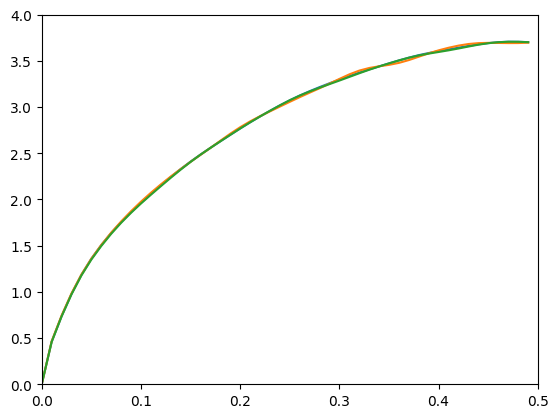

(0.0, 4.0)

In [11]:
plot(qs, plasmon_default)
plot(qs, plasmon_scipy)
plot(qs, plasmon_quadgk)
xlim(0, 0.5)
ylim(0, 4)

In [9]:
tau_allen_inv = zeros(100)
N = 200
for i in 1:N
    tau_allen_inv += 1 ./ np.loadtxt("../../BN3BC_Buckled/phonon22/tau/tau.out-$i")
end
tau_allen_inv *= 1/N 
tau_allen22 = 1 ./ tau_allen_inv;

In [4]:
tau_allen_inv = zeros(100)
N = 200
for i in 1:N
    tau_allen_inv += 1 ./ np.loadtxt("../../BN3BC_Buckled/phonon11/tau/tau.out-$i")
end
tau_allen_inv *= 1/N 
tau_allen11 = 1 ./ tau_allen_inv;

In [10]:
omegas = 0.01:0.01:1;
np.savetxt("tau_allen.txt", hcat(omegas, tau_allen22))

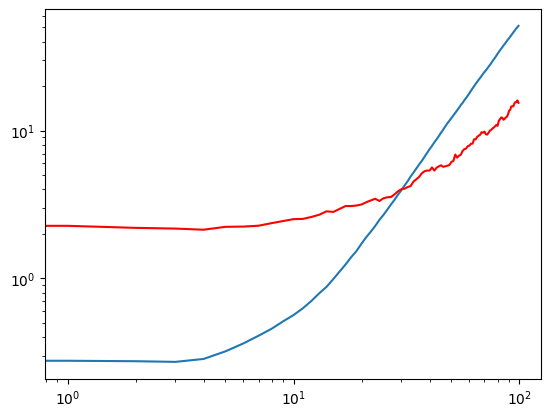

1-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f48cc255fa0>

In [9]:
loglog(tau_allen11)
loglog(tau_allen22, color="red")

#ylim(1, 1000)

In [11]:
np.loadtxt("tau_allen.txt")

100×2 Matrix{Float64}:
 0.01   2.09784
 0.02   2.26687
 0.03   2.19591
 0.04   2.17127
 0.05   2.13351
 0.06   2.23174
 0.07   2.24039
 0.08   2.27054
 0.09   2.36379
 0.1    2.44259
 0.11   2.5157
 0.12   2.52471
 0.13   2.60313
 ⋮     
 0.89  12.4285
 0.9   12.8964
 0.91  13.6473
 0.92  13.8315
 0.93  14.5832
 0.94  14.6066
 0.95  14.6501
 0.96  15.3212
 0.97  15.586
 0.98  15.6148
 0.99  16.0203
 1.0   15.4371